<a href="https://colab.research.google.com/github/DrDourado/ME_615_Spring_2026/blob/main/ME_615_Introduction_to_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to Image Classification and CNNs

Image classification is a fundamental task in computer vision that involves categorizing an image into one of several predefined classes. For humans, this task is often intuitive; we can instantly recognize objects, animals, or scenes. However, for computers, it's a challenging problem due to several factors:

*   **Variability:** Objects can appear in different positions, scales, orientations, and under varying lighting conditions.
*   **Deformation:** Objects can be non-rigid and change shape.
*   **Occlusion:** Parts of an object might be hidden from view.
*   **Intra-class Variation:** Different instances of the same class can look quite different (e.g., various breeds of dogs).
*   **Complexity of Features:** Traditional programming struggles to define explicit rules for recognizing complex visual patterns.

### Convolutional Neural Networks (CNNs)

Convolutional Neural Networks (CNNs) have emerged as a powerful and highly effective solution for image classification and other computer vision tasks. Unlike traditional neural networks that treat images as flat arrays of pixels, CNNs are specifically designed to process pixel data that has a known grid-like topology, such as image and video data.

The main advantage of CNNs over traditional neural networks for image data lies in their ability to automatically and adaptively learn spatial hierarchies of features from the input images through the use of **convolutional layers**. This eliminates the need for manual feature engineering, which is often a laborious and domain-specific process in traditional image processing. CNNs can capture local patterns (like edges, textures, and simple shapes) in early layers and then combine them into more complex, abstract patterns (like parts of objects or entire objects) in deeper layers.

### Typical CNN Architecture Overview

A Convolutional Neural Network typically consists of several layers, each performing a specific function. The common layers found in most CNN architectures include:

1.  **Input Layer:** This layer holds the raw pixel values of the image, e.g., 32x32x3 for a 32x32 pixel image with 3 color channels (RGB).

2.  **Convolutional Layer (CONV):** This is the core building block of a CNN. It applies a set of learnable filters (also called kernels) to the input image. Each filter convolves across the spatial dimensions of the input, computing the dot product between the filter entries and the input. This operation produces a 2D activation map (or feature map) that shows where the filter detects specific features in the input. Multiple filters are used to learn different features.

3.  **Activation Layer (ReLU):** After each convolutional layer, an activation function (commonly Rectified Linear Unit - ReLU) is applied element-wise. ReLU introduces non-linearity into the model, allowing it to learn more complex patterns. It outputs the input directly if it's positive, otherwise, it outputs zero (f(x) = max(0, x)).

4.  **Pooling Layer (POOL):** This layer periodically reduces the spatial dimensions (width and height) of the input representation, which helps to reduce the number of parameters and computational cost, and to control overfitting. Common pooling operations include Max Pooling (taking the maximum value in a window) and Average Pooling. It helps make the representations more robust to small translations and distortions.

5.  **Fully Connected Layer (FC):** Towards the end of the network, after several convolutional and pooling layers, the high-level features learned by the CNN are fed into one or more fully connected layers. These layers are similar to those in traditional Artificial Neural Networks, where every neuron in the previous layer is connected to every neuron in the next layer. They learn non-linear combinations of the high-level features.

6.  **Output Layer (Softmax/Sigmoid):** The final fully connected layer typically has an output unit for each class. For multi-class classification, a Softmax activation function is used to produce probabilities for each class. For binary classification, a Sigmoid function is often used.

Here's a conceptual diagram illustrating the flow:

```
Input Image -> CONV -> ReLU -> POOL -> CONV -> ReLU -> POOL -> FC -> FC -> Output (Classification)
```

This sequence of layers allows CNNs to hierarchically learn features, from simple edges and textures in early layers to more complex and abstract representations in deeper layers, ultimately leading to accurate image classification.

In [11]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("CIFAR-10 dataset loaded and class names defined.")

CIFAR-10 dataset loaded and class names defined.


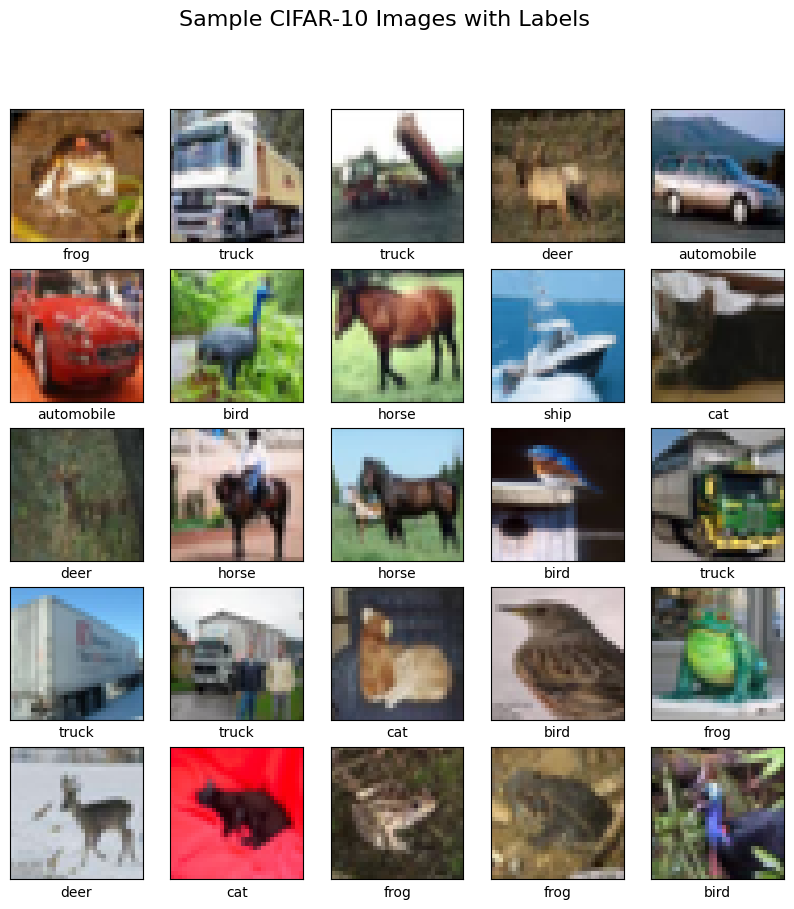

In [12]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    # The CIFAR-10 labels are arrays, so we need to access the first element
    plt.xlabel(class_names[y_train[i][0]])
plt.suptitle('Sample CIFAR-10 Images with Labels', fontsize=16)
plt.show()

## Convolution Operation Explained

### What is Convolution?

At the heart of Convolutional Neural Networks (CNNs) is the **convolution operation**. This mathematical operation involves two functions (or, in the context of images, an image and a filter) to produce a third function that expresses how the shape of one is modified by the other. In image processing, convolution is used to apply a "filter" or "kernel" to an input image to produce a "feature map" or "activation map" that highlights certain features like edges, textures, or patterns.

### How it Works:

1.  **Input:** We start with an input array, typically a 2D matrix representing an image (e.g., pixel intensities).
2.  **Filter (Kernel):** A small matrix (e.g., 3x3, 5x5) called a filter or kernel is defined. This filter is essentially a set of learnable weights that detect specific features. Different filters detect different features (e.g., horizontal edges, vertical edges, blurs).
3.  **Sliding Window:** The filter "slides" or "convolves" across the input image. It moves step by step across the width and height of the image.
4.  **Element-wise Multiplication and Summation:** At each position, the filter overlaps a patch of the input image. We perform an element-wise multiplication between the values in the filter and the corresponding values in the input image patch. All these products are then summed up to produce a single numerical value. This single value becomes one pixel in the output feature map.
5.  **Output Feature Map:** This process is repeated for every possible position the filter can slide over the input image, generating a new matrix called the feature map. Each value in the feature map indicates the presence and strength of the feature detected by the filter at that specific location in the input image.

### Key Concepts:

*   **Filter (Kernel):** A small matrix of weights that slides over the input. Its values are learned during training.
*   **Feature Map (Activation Map):** The output of the convolution operation, showing where the filter detected specific features.
*   **Stride:** The number of pixels the filter shifts over the input matrix. A stride of 1 means the filter moves one pixel at a time. Larger strides reduce the spatial dimensions of the output feature map.
*   **Padding:** Adding extra pixels (usually zeros) around the border of the input image. Padding is used to prevent the output feature map from shrinking too much or to ensure that the filter can cover all input pixels.

### Simple Example (Stride = 1, No Padding):

Let's consider a small 4x4 input image and a 3x3 filter:

**Input Image (4x4):**
```
[[1, 1, 1, 0],
 [0, 1, 1, 1],
 [0, 0, 1, 1],
 [0, 0, 0, 1]]
```

**Filter (3x3 - e.g., a simple edge detector):**
```
[[-1, -1, -1],
 [-1,  8, -1],
 [-1, -1, -1]]
```

**Step 1: Filter over top-left corner (first 3x3 patch)**
```
Input patch:  [[1, 1, 1],
               [0, 1, 1],
               [0, 0, 1]]

Filter:       [[-1, -1, -1],
               [-1,  8, -1],
               [-1, -1, -1]]
```
Element-wise multiplication and summation:
(1*-1) + (1*-1) + (1*-1) +
(0*-1) + (1*8) + (1*-1) +
(0*-1) + (0*-1) + (1*-1)
= -1 -1 -1 + 0 + 8 -1 + 0 + 0 -1 = **3**

**Step 2: Filter shifts one position to the right**
```
Input patch:  [[1, 1, 0],
               [1, 1, 1],
               [0, 1, 1]]
```
(1*-1) + (1*-1) + (0*-1) +
(1*-1) + (1*8) + (1*-1) +
(0*-1) + (1*-1) + (1*-1)
= -1 -1 + 0 -1 + 8 -1 + 0 -1 -1 = **2**

**Step 3: Filter shifts one position down (starting from the left)**
```
Input patch:  [[0, 1, 1],
               [0, 0, 1],
               [0, 0, 0]]
```
(0*-1) + (1*-1) + (1*-1) +
(0*-1) + (0*8) + (1*-1) +
(0*-1) + (0*-1) + (0*-1)
= 0 -1 -1 + 0 + 0 -1 + 0 + 0 + 0 = **-3**

**Step 4: Filter shifts one position to the right**
```
Input patch:  [[1, 1, 1],
               [0, 1, 1],
               [0, 0, 1]]
```
(1*-1) + (1*-1) + (1*-1) +
(0*-1) + (1*8) + (1*-1) +
(0*-1) + (0*-1) + (1*-1)
= -1 -1 -1 + 0 + 8 -1 + 0 + 0 -1 = **3**

**Output Feature Map (2x2):**
```
[[ 3,  2],
 [-3,  3]]
```

As you can see, the output is smaller than the input when no padding is used. This process allows CNNs to extract hierarchical features by applying many different filters across the image.

In [13]:
import numpy as np
from scipy.signal import convolve2d

print("Numpy and scipy.signal.convolve2d imported.")

# 3. Create a small, synthetic 2D numpy array representing a simple image
# Let's create a 5x5 image with a vertical line in the middle
input_image = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0]
])

# 4. Define a simple filter (kernel), for instance, a 3x3 edge detection filter.
# This filter detects vertical edges
vertical_edge_filter = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

print("\n--- Input Image ---")
print(input_image)

print("\n--- Filter (Vertical Edge Detector) ---")
print(vertical_edge_filter)

# 5. Apply the convolution operation
# Using mode='valid' means no padding, the output size will be (input_rows - filter_rows + 1) x (input_cols - filter_cols + 1)
output_feature_map = convolve2d(input_image, vertical_edge_filter, mode='valid')

# 6. Print the input image, the filter, and the resulting feature map
print("\n--- Output Feature Map (Convolution Result) ---")
print(output_feature_map)


Numpy and scipy.signal.convolve2d imported.

--- Input Image ---
[[0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]]

--- Filter (Vertical Edge Detector) ---
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

--- Output Feature Map (Convolution Result) ---
[[-3  0  3]
 [-3  0  3]
 [-3  0  3]]


### Interpretation of Convolution Result

In the example above, we applied a vertical edge detection filter to a simple synthetic image containing a vertical line. Let's analyze the output:

*   **Input Image:** We had a 5x5 image with a central column of `1`s (representing the vertical line) and `0`s elsewhere.

*   **Vertical Edge Filter:** The 3x3 filter was designed to highlight vertical changes. It has negative values on the left, zeros in the middle, and positive values on the right.

*   **Output Feature Map:**
    ```
    [[-3  0  3]
     [-3  0  3]
     [-3  0  3]]
    ```
    -   The `0`s in the middle column of the output indicate that the filter found **no vertical edge** when its center was directly on the vertical line in the input image. This is because the sum of products for a perfect vertical line centered under this specific filter would be zero.
    -   The `-3`s on the left column indicate a strong response where the filter detected the **left side of the vertical line**. The values change from 0 to 1, and the negative weights of the filter are activated.
    -   The `3`s on the right column indicate a strong response where the filter detected the **right side of the vertical line**. The values change from 1 to 0, and the positive weights of the filter are activated.

This demonstrates how a specific filter can effectively detect and highlight a particular feature (in this case, a vertical edge) in an image by producing high activation values where the feature is present and low (or zero) values where it is not.

## Filters (Kernels) and Feature Maps: The Core of CNNs

Filters, also known as kernels, are at the very heart of how Convolutional Neural Networks perceive and understand images. They are small matrices of numbers that act as feature detectors.

### What are Filters?

Imagine a filter as a magnifying glass that's looking for a very specific pattern, like an edge, a corner, or a particular texture. Each filter has a unique set of weights (the numbers within the matrix) that are designed to activate when that specific pattern is present in the input image. During the training of a CNN, the network learns the optimal values for these weights, allowing it to automatically discover salient features in the images.

### How Filters Generate Feature Maps:

When a filter slides across an input image (or a feature map from a previous layer), it performs the convolution operation: element-wise multiplication and summation. The result of this operation at each position is a single value that indicates how strongly the filter's specific pattern was detected in that region of the input. These resulting values, when collected together, form a **feature map** (also called an activation map).

*   A high value in the feature map means the filter found its characteristic pattern strongly in that corresponding region of the input.
*   A low value (or negative) means the pattern was absent or detected in an inverse way.

Each feature map essentially highlights the locations where a particular feature (defined by its filter) is present in the input. A CNN typically uses many different filters in a convolutional layer, with each filter learning to detect a different feature. This results in a stack of multiple feature maps, each corresponding to a different learned feature.

### Reiteration of Stride and Padding:

**Stride** and **Padding** play crucial roles in controlling the size of the feature maps and how the filters interact with the input:

*   **Stride:** This parameter determines the step size the filter takes as it slides across the input. A stride of 1 means the filter moves one pixel at a time. A larger stride (e.g., 2 or 3) means the filter jumps more pixels, resulting in a smaller output feature map. Larger strides can help reduce the computational cost and the spatial dimensions of the representation.

*   **Padding:** When a filter is applied to an image, especially near the edges, the output feature map can become smaller than the input image. This is because the filter cannot fully overlap with pixels on the border. Padding involves adding extra pixels (usually zeros) around the border of the input image. This allows the filter to cover all input pixels and helps to:
    *   Preserve the spatial dimensions of the input (maintain the same height and width).
    *   Ensure that information at the borders of the image is used equally often in the convolution process, preventing information loss from the edges.

By strategically using different filters, strides, and padding, CNNs can efficiently extract a rich hierarchy of features, from simple low-level patterns to complex high-level representations, which are then used for classification.

Original CIFAR-10 Image Shape: (32, 32, 3)
Grayscale Image Shape: (32, 32)
Selected Image Patch (8x8) from Grayscale:
[[ 48  62  55  65 100  96 101  87]
 [ 69  96  89 125 125 110 124 107]
 [ 89 158 130 156 176 154 170 170]
 [117 182 141 161 218 195 193 191]
 [159 154 108 169 203 227 227 219]
 [197 104 117 165 171 235 251 249]
 [186 102 146 165 193 229 238 232]
 [151 130 183 201 210 219 213 188]]
Image Patch Shape: (8, 8)


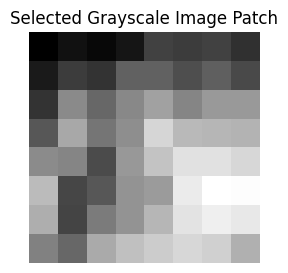

In [14]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt

# Helper function to convert RGB image to grayscale
def rgb_to_grayscale(rgb_image):
    # Using the standard luminosity method: 0.2989 * R + 0.5870 * G + 0.1140 * B
    return np.dot(rgb_image[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

# Select a small patch from one of the CIFAR-10 training images
# We'll use the first image from x_train
original_cifar_image = x_train[0]

# Convert to grayscale for simpler 2D convolution demonstration
grayscale_image = rgb_to_grayscale(original_cifar_image)

# Extract a 8x8 patch from the grayscale image
# This makes the visualization of convolution results more manageable
image_patch = grayscale_image[10:18, 10:18] # Adjust coordinates as needed for a good feature

print("Original CIFAR-10 Image Shape:", original_cifar_image.shape)
print("Grayscale Image Shape:", grayscale_image.shape)
print("Selected Image Patch (8x8) from Grayscale:")
print(image_patch)
print("Image Patch Shape:", image_patch.shape)

# Visualize the selected patch
plt.figure(figsize=(3,3))
plt.imshow(image_patch, cmap='gray')
plt.title('Selected Grayscale Image Patch')
plt.axis('off')
plt.show()


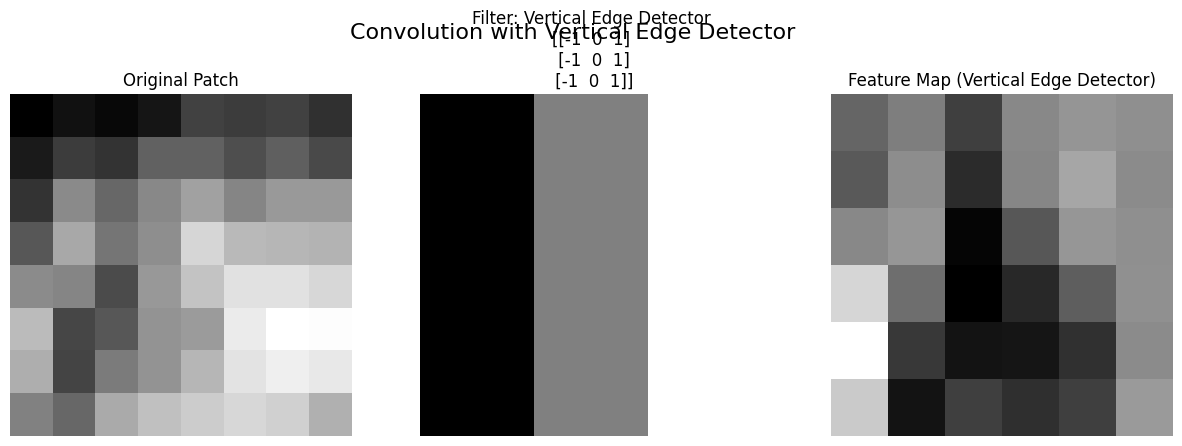

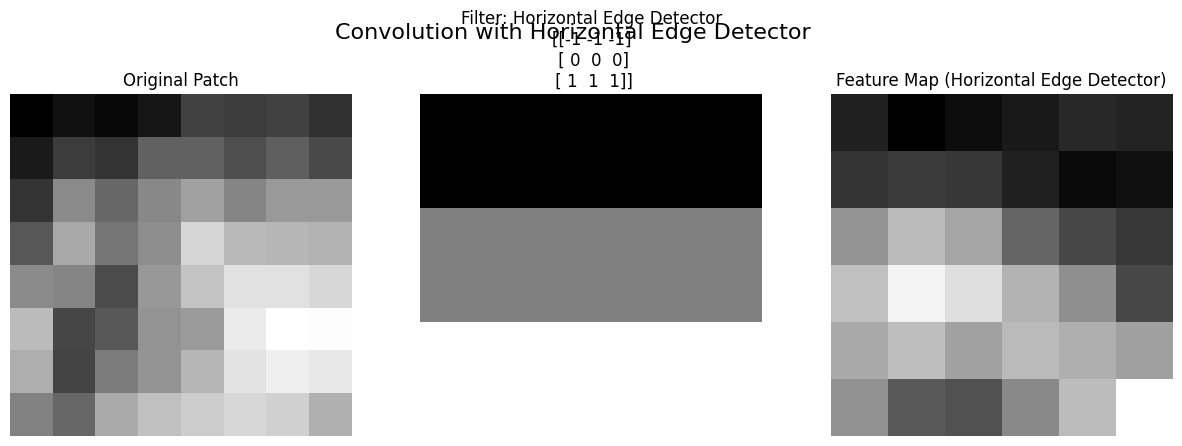

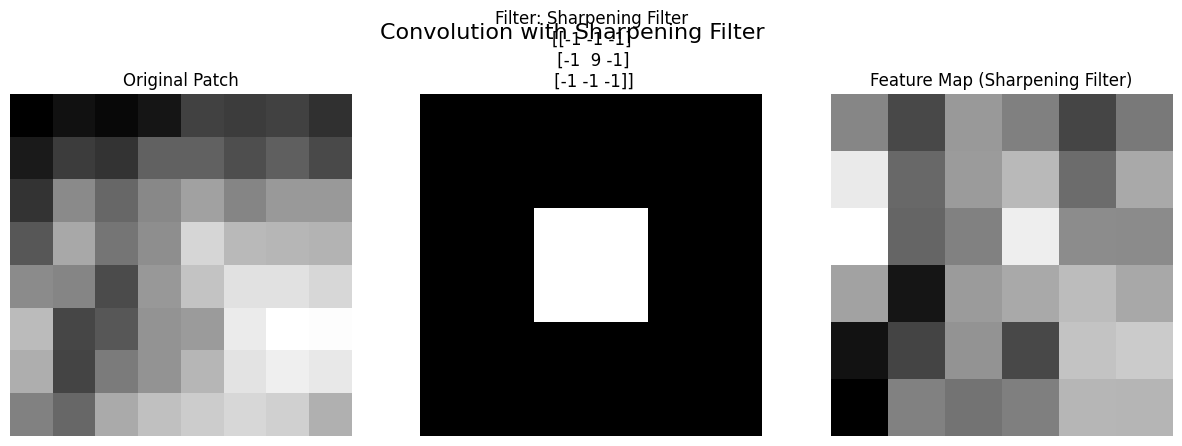

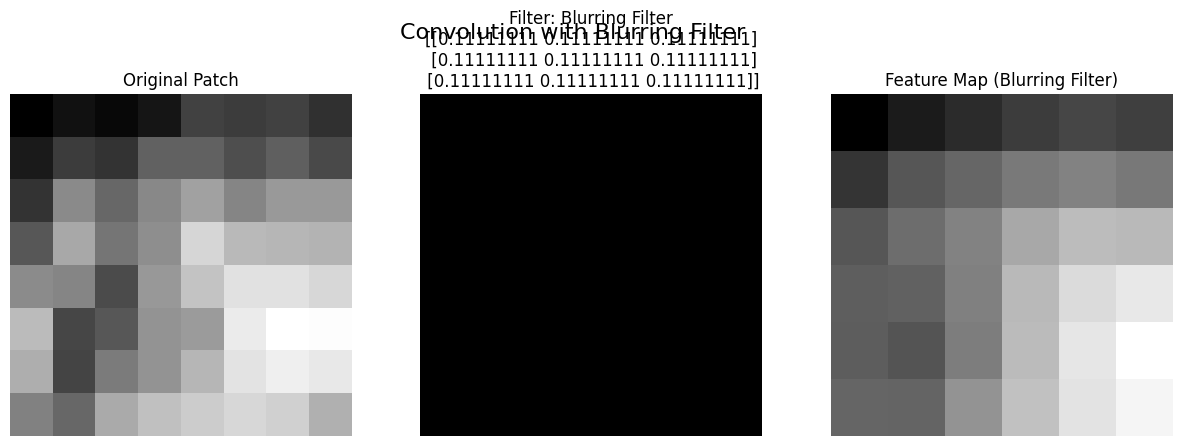

In [15]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt

# Define different 3x3 filters
filters = {
    "Vertical Edge Detector": np.array([[-1, 0, 1],
                                        [-1, 0, 1],
                                        [-1, 0, 1]]),
    "Horizontal Edge Detector": np.array([[-1, -1, -1],
                                          [ 0,  0,  0],
                                          [ 1,  1,  1]]),
    "Sharpening Filter": np.array([[-1, -1, -1],
                                     [-1,  9, -1],
                                     [-1, -1, -1]]),
    "Blurring Filter": (1/9) * np.array([[1, 1, 1],
                                        [1, 1, 1],
                                        [1, 1, 1]])
}

# Visualize the application of each filter
for filter_name, current_filter in filters.items():
    # Apply the convolution operation
    # mode='valid' means no padding, output size will be (input_rows - filter_rows + 1) x (input_cols - filter_cols + 1)
    feature_map = convolve2d(image_patch, current_filter, mode='valid')

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_patch, cmap='gray')
    plt.title('Original Patch')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(current_filter, cmap='gray') # Visualize the filter matrix itself
    plt.title(f'Filter: {filter_name}\n{current_filter}')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(feature_map, cmap='gray')
    plt.title(f'Feature Map ({filter_name})')
    plt.axis('off')

    plt.suptitle(f'Convolution with {filter_name}', fontsize=16)
    plt.show()

### Interpretation of Feature Maps with Different Filters

Let's analyze the feature maps generated by applying different filters to our selected grayscale image patch:

1.  **Vertical Edge Detector:**
    *   **Filter Design:** This filter has negative values on the left, zeros in the middle, and positive values on the right. It's designed to respond strongly to changes in pixel intensity from left to right, indicating vertical edges.
    *   **Feature Map Interpretation:** Areas with strong vertical lines (where pixel values change rapidly horizontally) will show high absolute values in the feature map. Positive values indicate a transition from dark to light from left to right, while negative values indicate a transition from light to dark. The feature map effectively highlights the vertical boundaries within the image patch.

2.  **Horizontal Edge Detector:**
    *   **Filter Design:** This filter typically has negative values on top, zeros in the middle, and positive values on the bottom (or vice-versa). It's designed to respond strongly to changes in pixel intensity from top to bottom, indicating horizontal edges.
    *   **Feature Map Interpretation:** Similar to the vertical edge detector, this feature map will show high absolute values where strong horizontal lines or intensity changes occur vertically. Positive values might indicate a dark-to-light transition downwards, and negative for light-to-dark. This map outlines the horizontal structures in the patch.

3.  **Sharpening Filter:**
    *   **Filter Design:** A common sharpening filter subtracts blurred versions of the image from the original, emphasizing details and edges. It usually has a large positive center weight and negative weights around it, designed to enhance differences between a pixel and its neighbors.
    *   **Feature Map Interpretation:** The sharpening filter's output feature map will appear to have enhanced edges and finer details compared to the original image. Areas that already have high contrast will become even more pronounced, making the image look 'sharper'. This is achieved by increasing the intensity difference between adjacent pixels.

4.  **Blurring Filter:**
    *   **Filter Design:** A blurring filter (like the average filter used here) assigns equal positive weights to all pixels within its window. It averages the pixel intensities in a local neighborhood.
    *   **Feature Map Interpretation:** The blurring filter's output feature map will appear smoother than the original patch. Sharp edges and noise are reduced because each pixel's value is replaced by the average of itself and its neighbors. This effectively reduces high-frequency components in the image, making it less detailed but potentially reducing noise.

## Strides and Padding: Controlling Feature Map Dimensions

In the convolution operation, two critical hyperparameters significantly influence the size and characteristics of the output feature map: **Stride** and **Padding**.

### Stride

**Stride** defines the step size the filter takes as it slides across the input volume (image or previous feature map). It dictates how many pixels the filter shifts horizontally and vertically at each step.

*   **Stride of 1 (default):** The filter moves one pixel at a time. This results in an output feature map that is only slightly smaller than the input (depending on filter size and padding).
*   **Stride > 1:** The filter skips pixels, moving multiple pixels at once. This effectively downsamples the spatial dimensions of the input, leading to a smaller output feature map. Larger strides reduce the computational cost and the number of parameters, and can help capture broader features.

**Effect on Output Size (without padding):**
If `I` is the input dimension (height or width) and `K` is the filter dimension (height or width):

Output Dimension `O = (I - K) / S + 1`

Where `S` is the stride. The result must be an integer, meaning `(I - K)` must be divisible by `S`.

### Padding

When a filter convolves over an image, especially with `stride=1` and `K > 1`, the output feature map typically shrinks in size compared to the input. This shrinkage can lead to loss of information, especially at the borders of the image, as border pixels are involved in fewer convolution operations.

**Padding** is the technique of adding extra pixels, usually with zero values (zero-padding), around the border of the input image or feature map before applying the convolution. This helps to control the spatial dimensions of the output feature map.

Common padding types:

*   **'Valid' (No Padding):** This is the default in many frameworks if not specified. The convolution is applied only where the filter fully overlaps with the input. The output feature map will be smaller than the input.
*   **'Same' (Zero-Padding):** Padding is added to the input such that the output feature map has the *same* spatial dimensions as the input, provided a stride of 1. The amount of padding is calculated automatically to achieve this.

**Effect on Output Size (with padding):**
If `I` is the input dimension, `K` is the filter dimension, `S` is the stride, and `P` is the total padding applied (e.g., `P = P_left + P_right`):

Output Dimension `O = (I - K + 2P) / S + 1`

This formula allows us to calculate the exact output dimensions for any given input, filter, stride, and padding configuration.

Understanding strides and padding is crucial for designing CNN architectures, as they directly impact the spatial dimensions of feature maps throughout the network and, consequently, the network's capacity and computational efficiency.

In [16]:
import numpy as np
from scipy.signal import convolve2d

# Assuming image_patch is already defined from previous steps
# For demonstration, let's ensure image_patch exists (if running this cell independently)
# if 'image_patch' not in globals():
#     # Fallback: create a dummy image patch if not already present
#     print("Warning: 'image_patch' not found, creating a dummy 8x8 patch.")
#     image_patch = np.random.randint(0, 256, size=(8, 8), dtype=np.uint8)

# Define a simple 3x3 filter (e.g., identity filter for observation of size changes)
simple_filter = np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]])

print(f"Input Image Patch Shape: {image_patch.shape}")
print(f"Filter Shape: {simple_filter.shape}")

# --- Demonstrate 'valid' padding (no padding) ---
# The output size will be (Input_Dim - Filter_Dim + 1)
feature_map_valid = convolve2d(image_patch, simple_filter, mode='valid')
print(f"\nFeature Map Shape with mode='valid' (no padding): {feature_map_valid.shape}")

# --- Demonstrate 'same' padding (zero-padding to maintain size) ---
# The output size will be the same as the input size, assuming stride 1
feature_map_same = convolve2d(image_patch, simple_filter, mode='same')
print(f"Feature Map Shape with mode='same' (zero-padding): {feature_map_same.shape}")

# Visualizing a small part of the results to see the effect
print("\n--- Excerpt of Input Image Patch ---")
print(image_patch[:5, :5])
print("\n--- Excerpt of Feature Map (valid) ---")
print(feature_map_valid[:3, :3]) # Smaller output, so show less
print("\n--- Excerpt of Feature Map (same) ---")
print(feature_map_same[:5, :5]) # Same size output, so show more


Input Image Patch Shape: (8, 8)
Filter Shape: (3, 3)

Feature Map Shape with mode='valid' (no padding): (6, 6)
Feature Map Shape with mode='same' (zero-padding): (8, 8)

--- Excerpt of Input Image Patch ---
[[ 48  62  55  65 100]
 [ 69  96  89 125 125]
 [ 89 158 130 156 176]
 [117 182 141 161 218]
 [159 154 108 169 203]]

--- Excerpt of Feature Map (valid) ---
[[ 96  89 125]
 [158 130 156]
 [182 141 161]]

--- Excerpt of Feature Map (same) ---
[[ 48  62  55  65 100]
 [ 69  96  89 125 125]
 [ 89 158 130 156 176]
 [117 182 141 161 218]
 [159 154 108 169 203]]


In [17]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D
import numpy as np

# Assuming image_patch is defined from previous steps (8x8 numpy array)
# Reshape image_patch to (batch, height, width, channels) for Conv2D layer
# Add a batch dimension of 1 and a channel dimension of 1 (since it's grayscale)
dummy_input = np.expand_dims(np.expand_dims(image_patch, axis=0), axis=-1)
dummy_input = tf.convert_to_tensor(dummy_input, dtype=tf.float32)

print(f"Original Image Patch Shape: {image_patch.shape}")
print(f"Dummy Input Tensor Shape for Conv2D: {dummy_input.shape}\n")

# Define a simple 3x3 filter (kernel_size)
kernel_size = (3, 3)
filters = 1 # We'll use 1 filter for simplicity

# --- Conv2D with strides=(1,1), padding='valid' ---
conv_valid_s1 = Conv2D(filters=filters, kernel_size=kernel_size, strides=(1,1), padding='valid', use_bias=False)
output_valid_s1 = conv_valid_s1(dummy_input)
print(f"Output shape with strides=(1,1), padding='valid': {output_valid_s1.shape}")

# --- Conv2D with strides=(2,2), padding='valid' ---
conv_valid_s2 = Conv2D(filters=filters, kernel_size=kernel_size, strides=(2,2), padding='valid', use_bias=False)
output_valid_s2 = conv_valid_s2(dummy_input)
print(f"Output shape with strides=(2,2), padding='valid': {output_valid_s2.shape}")

# --- Conv2D with strides=(1,1), padding='same' ---
conv_same_s1 = Conv2D(filters=filters, kernel_size=kernel_size, strides=(1,1), padding='same', use_bias=False)
output_same_s1 = conv_same_s1(dummy_input)
print(f"Output shape with strides=(1,1), padding='same': {output_same_s1.shape}")

# --- Conv2D with strides=(2,2), padding='same' ---
# This is also a common case to show how padding='same' works with strides > 1
conv_same_s2 = Conv2D(filters=filters, kernel_size=kernel_size, strides=(2,2), padding='same', use_bias=False)
output_same_s2 = conv_same_s2(dummy_input)
print(f"Output shape with strides=(2,2), padding='same': {output_same_s2.shape}")

Original Image Patch Shape: (8, 8)
Dummy Input Tensor Shape for Conv2D: (1, 8, 8, 1)

Output shape with strides=(1,1), padding='valid': (1, 6, 6, 1)
Output shape with strides=(2,2), padding='valid': (1, 3, 3, 1)
Output shape with strides=(1,1), padding='same': (1, 8, 8, 1)
Output shape with strides=(2,2), padding='same': (1, 4, 4, 1)


## Non-linearity via Activation Functions

### The Need for Non-linearity

In neural networks, including CNNs, layers often perform linear operations. For example, a convolutional layer performs a series of multiplications and additions. If we only stacked linear layers one after another, the entire network would still behave like a single linear operation, regardless of its depth. A linear model, however, has limited expressive power; it can only learn linear relationships between inputs and outputs. This means it would be incapable of understanding complex patterns, shapes, and relationships present in image data, which are inherently non-linear.

To overcome this limitation and enable neural networks to learn intricate, non-linear relationships, **activation functions** are introduced after each linear operation (like convolution or matrix multiplication in fully connected layers).

### What are Activation Functions?

Activation functions are mathematical equations that determine whether a neuron should be activated or not, based on the weighted sum of its inputs. They introduce non-linearity into the network, allowing it to learn complex functions and model more sophisticated patterns. Without activation functions, deep neural networks would simply be equivalent to a single-layer network.

### Rectified Linear Unit (ReLU)

One of the most popular and widely used activation functions in CNNs is the **Rectified Linear Unit (ReLU)**. Its mathematical definition is incredibly simple:

`f(x) = max(0, x)`

This means:
*   If the input `x` is positive, the output is `x`.
*   If the input `x` is zero or negative, the output is `0`.

#### Benefits of ReLU:

1.  **Non-linearity:** It introduces non-linearity, allowing the model to learn more complex functions.
2.  **Computational Efficiency:** Compared to other activation functions like sigmoid or tanh, ReLU involves very simple operations (a comparison and a maximum), making it very fast to compute.
3.  **Mitigates Vanishing Gradient Problem:** For positive inputs, the gradient is always 1, which helps to combat the vanishing gradient problem often encountered with sigmoid or tanh functions in deep networks.
4.  **Sparsity:** It can lead to sparse activations, meaning a significant portion of neurons will output zero, which can also help with computational efficiency and act as a form of regularization.

By applying ReLU after a convolutional layer, we ensure that only the positively activated features are passed on to the next layer, effectively filtering out less relevant or negative activations and introducing the crucial non-linearity needed for deep learning models to excel.

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D
import numpy as np
import matplotlib.pyplot as plt

# Ensure dummy_input is available from previous steps
# Reshape image_patch to (batch, height, width, channels) for Conv2D layer
# Add a batch dimension of 1 and a channel dimension of 1 (since it's grayscale)
dummy_input = np.expand_dims(np.expand_dims(image_patch, axis=0), axis=-1)
dummy_input = tf.convert_to_tensor(dummy_input, dtype=tf.float32)

print(f"Dummy Input Tensor Shape for Conv2D: {dummy_input.shape}")

# Define a simple 3x3 filter (e.g., vertical edge detector from previous steps)
# Need to reshape the numpy filter for use as a Keras kernel (height, width, in_channels, out_channels)
# Since input has 1 channel and we want 1 output feature map, it's (3, 3, 1, 1)
vertical_edge_filter_keras = np.array([[-1, 0, 1],
                                     [-1, 0, 1],
                                     [-1, 0, 1]], dtype=np.float32)
vertical_edge_filter_keras = np.expand_dims(np.expand_dims(vertical_edge_filter_keras, axis=-1), axis=-1)

# Create a Conv2D layer with the defined filter and parameters
# We'll set use_bias=False for simplicity, as bias is not the focus here
conv_layer = Conv2D(filters=1, kernel_size=(3, 3), strides=(1,1), padding='valid', use_bias=False)

# Build the layer to assign the weights
conv_layer.build(dummy_input.shape)
# Set the weights of the convolutional layer to our predefined filter
conv_layer.set_weights([vertical_edge_filter_keras])

# Apply the convolution to get the feature map before activation
pre_activation_feature_map = conv_layer(dummy_input)

print(f"\nShape of the pre-activation feature map: {pre_activation_feature_map.shape}")

# Squeeze the dimensions for easier plotting (remove batch and channel dimensions)
pre_activation_np = pre_activation_feature_map.numpy().squeeze()

print("\nPre-activation Feature Map (excerpt):\n", pre_activation_np[:3,:3])

Dummy Input Tensor Shape for Conv2D: (1, 8, 8, 1)

Shape of the pre-activation feature map: (1, 6, 6, 1)

Pre-activation Feature Map (excerpt):
 [[ 68.  30. 127.]
 [ 85.   6. 159.]
 [ 14.  -8. 218.]]


Shape of the post-activation feature map: (6, 6)

Post-activation Feature Map (excerpt):
 [[ 68.  30. 127.]
 [ 85.   6. 159.]
 [ 14.   0. 218.]]


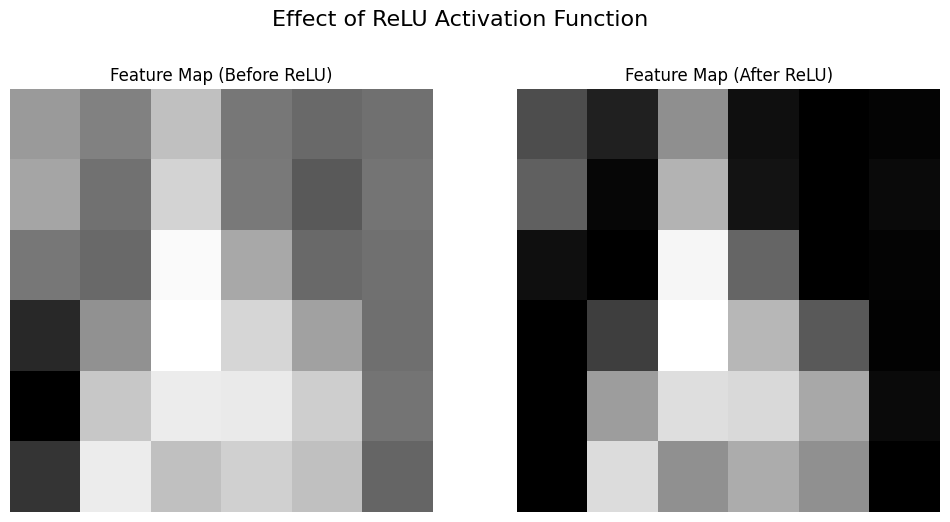

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Apply the ReLU activation function
post_activation_feature_map_tf = tf.nn.relu(pre_activation_feature_map)

# 2. Convert both pre- and post-activation feature maps to NumPy arrays and squeeze dimensions
# pre_activation_np is already done in the previous step
post_activation_np = post_activation_feature_map_tf.numpy().squeeze()

print(f"Shape of the post-activation feature map: {post_activation_np.shape}")
print("\nPost-activation Feature Map (excerpt):\n", post_activation_np[:3,:3])

# 3-8. Create and display the plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(pre_activation_np, cmap='gray')
plt.title('Feature Map (Before ReLU)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(post_activation_np, cmap='gray')
plt.title('Feature Map (After ReLU)')
plt.axis('off')

plt.suptitle('Effect of ReLU Activation Function', fontsize=16)
plt.show()

### Interpretation of ReLU Activation Effect

The visualization clearly demonstrates the impact of the Rectified Linear Unit (ReLU) activation function on the convolved feature map.

**Before ReLU (Left Plot):**
*   The feature map before applying ReLU contains both positive and negative values. These values represent the raw output of the convolution operation, indicating the strength and direction (e.g., presence or absence, or different types of edges) of features detected by the filter.
*   Negative values are visible as darker shades in the grayscale image, while positive values appear lighter.

**After ReLU (Right Plot):**
*   After applying the `f(x) = max(0, x)` function, all negative values in the feature map have been clamped to zero. These areas now appear completely black in the grayscale image, indicating no activation.
*   Only the positive activations remain, preserving their original values. These areas continue to show lighter shades, highlighting the regions where the convolutional filter found strong positive evidence for the feature it was designed to detect.

**Significance:**
*   **Non-linearity:** By setting negative values to zero, ReLU introduces crucial non-linearity into the network. This allows the CNN to learn more complex and diverse patterns than it could with only linear operations.
*   **Sparsity:** ReLU promotes sparsity in the activations, meaning fewer neurons are activated (outputting non-zero values). This can make the network more computationally efficient and help in learning more robust features.
*   **Feature Focus:** It helps the network to focus on the most relevant features by discarding activations that are deemed 'negative' or irrelevant for a particular filter's purpose. Only features that positively contribute to the detection are propagated forward.

## Pooling Layers

### What are Pooling Layers?

Pooling layers are an essential component of Convolutional Neural Networks (CNNs), typically inserted between successive convolutional layers. Their primary functions are to reduce the spatial dimensions (width and height) of the input representation, which helps to:

1.  **Reduce computational cost:** Fewer parameters mean faster computation and less memory usage.
2.  **Reduce overfitting:** By summarizing features, pooling layers help make the model more robust to noise and slight variations in the input.
3.  **Extract dominant features:** They highlight the most important features in a region, discarding less relevant information.
4.  **Achieve translational invariance:** Small shifts or distortions in the input image will lead to largely the same pooled output, making the network more robust to the precise location of features.

Pooling operations work by sliding a fixed-size window (often called the pooling window or kernel) over the input feature map and applying an aggregation function to the values within that window. The two most common types of pooling are Max Pooling and Average Pooling.

### Max Pooling

**Max Pooling** selects the maximum value within the pooling window. This operation is designed to retain the most prominent feature in each sub-region. If a specific feature (like an edge or corner) is detected strongly anywhere within a pooling window, its presence will be preserved in the output.

*   **How it works:** A pooling window (e.g., 2x2) slides across the input feature map. For each window, the largest value is taken and placed into the output feature map. All other values within that window are discarded.
*   **Benefits:** It helps to preserve the most important features, contributes to translational invariance, and dramatically reduces spatial dimensions.

### Average Pooling

**Average Pooling** calculates the average value within the pooling window. This operation tends to smooth out the feature map, making it less sensitive to noise or small variations, but might lose some fine-grained information compared to Max Pooling.

*   **How it works:** Similar to Max Pooling, a pooling window slides across the input. For each window, the average of all values within the window is calculated and placed into the output feature map.
*   **Benefits:** It provides a more generalized representation of the features in a region and can be useful in later stages of the network or for tasks where feature smoothing is desirable.

### Parameters:

*   **Pool Size (or Kernel Size):** Defines the dimensions of the pooling window (e.g., `(2, 2)` or `(3, 3)`).
*   **Strides:** Defines how many pixels the pooling window moves at each step. Commonly, `strides` are set equal to `pool_size` (e.g., `strides=(2, 2)` for a `pool_size=(2, 2)`), which results in non-overlapping pooling windows and a significant reduction in spatial dimensions (e.g., halving the width and height).

Both Max Pooling and Average Pooling are crucial for building efficient and effective CNN architectures, allowing the network to learn robust, hierarchical representations of image data.

Original Feature Map shape (after ReLU): (6, 6)
Max Pooled Feature Map shape: (3, 3)
Average Pooled Feature Map shape: (3, 3)


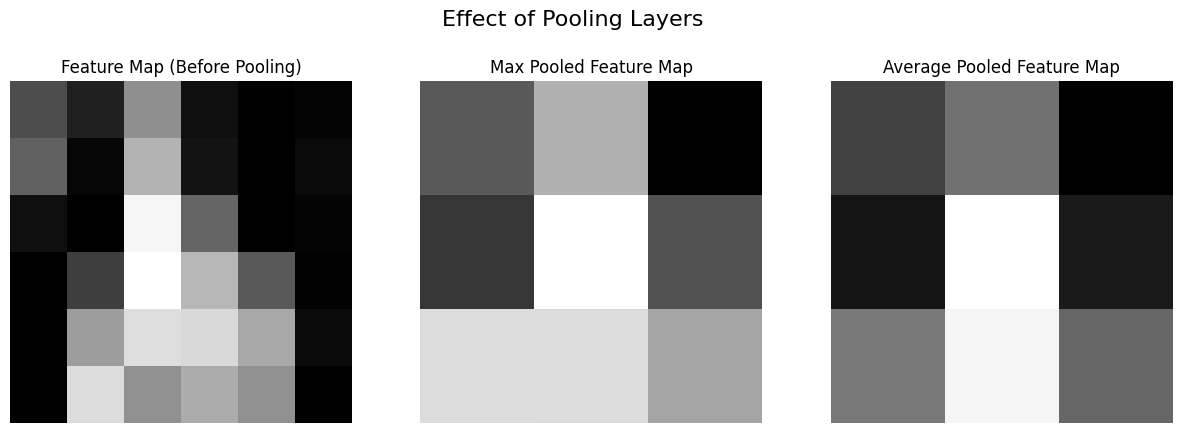

In [20]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Ensure pre_activation_feature_map and post_activation_feature_map_tf are available
# (from previous step, post_activation_feature_map_tf is the output after ReLU)

# Define pooling parameters
pool_size = (2, 2)
strides = (2, 2)

# Apply MaxPooling2D
max_pooling_layer = tf.keras.layers.MaxPooling2D(pool_size=pool_size, strides=strides, padding='valid')
max_pooled_feature_map_tf = max_pooling_layer(post_activation_feature_map_tf)

# Apply AveragePooling2D
avg_pooling_layer = tf.keras.layers.AveragePooling2D(pool_size=pool_size, strides=strides, padding='valid')
avg_pooled_feature_map_tf = avg_pooling_layer(post_activation_feature_map_tf)

# Convert to NumPy arrays and squeeze dimensions for plotting
post_activation_np = post_activation_feature_map_tf.numpy().squeeze() # Already done in previous step, but re-squeezing for clarity
max_pooled_np = max_pooled_feature_map_tf.numpy().squeeze()
avg_pooled_np = avg_pooled_feature_map_tf.numpy().squeeze()

print(f"Original Feature Map shape (after ReLU): {post_activation_np.shape}")
print(f"Max Pooled Feature Map shape: {max_pooled_np.shape}")
print(f"Average Pooled Feature Map shape: {avg_pooled_np.shape}")

# Visualize the effect of pooling
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(post_activation_np, cmap='gray')
plt.title('Feature Map (Before Pooling)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(max_pooled_np, cmap='gray')
plt.title('Max Pooled Feature Map')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(avg_pooled_np, cmap='gray')
plt.title('Average Pooled Feature Map')
plt.axis('off')

plt.suptitle('Effect of Pooling Layers', fontsize=16)
plt.show()

### Interpretation of Pooling Layer Effects

The visualization clearly illustrates the impact of Max Pooling and Average Pooling on the feature map, particularly in terms of dimensionality reduction and feature summarization.

**Original Feature Map (Left Plot):**
*   This plot shows the feature map after the convolution and ReLU activation. It has a spatial dimension of (6, 6), retaining a certain level of detail about the features detected by the preceding convolutional filter.

**Max Pooled Feature Map (Middle Plot):**
*   **Dimensionality Reduction:** With a `pool_size=(2, 2)` and `strides=(2, 2)`, the spatial dimensions of the feature map are reduced from (6, 6) to (3, 3). This is a 75% reduction in size, significantly cutting down on computation and parameters for subsequent layers.
*   **Feature Extraction:** Max Pooling selects the maximum value from each (2x2) region. This means it preserves the *strongest activation* or the *most dominant feature* detected within that region. If a specific feature (like an edge) was detected brightly in a sub-region, that bright activation is retained, while other, weaker activations or zero values are discarded. This makes the representation more robust to slight shifts in the feature's position (translational invariance).
*   **Appearance:** The Max Pooled map often looks sparser and highlights distinct bright spots, representing the peak activations of features.

**Average Pooled Feature Map (Right Plot):**
*   **Dimensionality Reduction:** Similar to Max Pooling, Average Pooling also reduces the spatial dimensions from (6, 6) to (3, 3) using the same pooling parameters.
*   **Feature Summarization:** Average Pooling computes the average value from each (2x2) region. This operation provides a more generalized or smoothed representation of the features in a region. It's less about highlighting the absolute strongest feature and more about capturing the overall presence of features.
*   **Appearance:** The Average Pooled map typically appears smoother and less distinct than the Max Pooled map. It averages out noise and subtle variations, which can sometimes be beneficial for robust learning, but might also lead to loss of fine-grained detail.

**Key Takeaways:**
*   Both pooling layers effectively reduce the spatial dimensions of the feature map, which is crucial for managing computational complexity and controlling overfitting in deeper CNNs.
*   Max Pooling excels at preserving the most prominent features and enhancing translational invariance.
*   Average Pooling provides a smoother, more generalized representation of features, which can help in reducing sensitivity to noise.

## Flatten Layers

### The Role of the Flatten Layer

After several layers of convolution and pooling, a Convolutional Neural Network (CNN) typically ends its feature extraction phase with multi-dimensional feature maps. These feature maps capture various spatial hierarchies of features from the input image. However, to perform classification or regression, these extracted features need to be fed into a traditional **Fully Connected (Dense)** neural network layer.

Fully connected layers expect a one-dimensional (1D) array of inputs, where each neuron in the layer is connected to every input in the previous layer. This creates a mismatch with the multi-dimensional output (e.g., `(height, width, channels)`) of the convolutional and pooling layers.

This is where the **Flatten layer** comes in.

### Purpose of the Flatten Layer:

The `Flatten` layer serves as a crucial bridge between the convolutional part of a CNN and its fully connected classification head. Its primary purpose is to transform the multi-dimensional output of the preceding layers (e.g., `(batch_size, height, width, channels)`) into a single, long one-dimensional vector (`(batch_size, height * width * channels)`).

Essentially, it takes all the elements from the multi-dimensional feature maps and arranges them sequentially into a single vector, without affecting the batch size. This flattened vector can then be used as input to a standard fully connected (Dense) neural network layer, allowing the network to learn complex non-linear combinations of the high-level features extracted by the convolutional layers for tasks like classification.

In [21]:
import tensorflow as tf
import numpy as np

# 2. Define a dummy multi-dimensional tensor (simulating output of a pooling layer)
# Let's assume a batch size of 1, height=3, width=3, and 32 channels (feature maps)
dummy_pooled_output = tf.random.normal(shape=(1, 3, 3, 32))

print(f"Shape of dummy pooled output (before Flatten): {dummy_pooled_output.shape}")

# 3. Instantiate a tf.keras.layers.Flatten() layer
flatten_layer = tf.keras.layers.Flatten()

# 4. Apply the Flatten layer to the dummy tensor
flattened_output = flatten_layer(dummy_pooled_output)

# 5. Print the shape of the input dummy tensor and the output of the Flatten layer
print(f"Shape of flattened output (after Flatten): {flattened_output.shape}")

Shape of dummy pooled output (before Flatten): (1, 3, 3, 32)
Shape of flattened output (after Flatten): (1, 288)


### Interpretation of Flatten Layer Output

The code example effectively demonstrates the transformation performed by the `Flatten` layer.

*   **Input Shape (`dummy_pooled_output`):** `(1, 3, 3, 32)`
    *   `1`: Represents the batch size (one sample).
    *   `3, 3`: Represent the spatial dimensions (height and width) of the feature map, indicating a 3x3 grid of features.
    *   `32`: Represents the number of channels or feature maps, meaning 32 different features were detected by the preceding convolutional/pooling layers for each spatial location.

*   **Output Shape (`flattened_output`):** `(1, 288)`
    *   `1`: The batch size remains unchanged, as `Flatten` operates on each sample independently.
    *   `288`: This is the crucial change. It's calculated by multiplying the spatial dimensions and the number of channels: `3 (height) * 3 (width) * 32 (channels) = 288`. The `Flatten` layer has reshaped the 3D feature map (per sample) into a single 1D vector of 288 features.

**Significance for Fully Connected Layers:**

This transformation is essential because **Fully Connected (Dense) layers** are designed to work with 1D input vectors. Each neuron in a Dense layer expects a single numerical input from each element of the previous layer. By flattening the multi-dimensional feature maps, the network converts the rich spatial information extracted by the convolutional layers into a format that the Dense layers can process. These Dense layers then learn to combine these high-level, flattened features to make final predictions for tasks like classification.

## Build a Simple CNN Model

Construct a basic CNN model using Keras/TensorFlow, incorporating all the discussed layers (Conv2D, Activation, MaxPooling, Flatten, Dense).

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 2. Create a Sequential model instance
model = Sequential()

# 3. Add the first Conv2D layer
# 32 filters, 3x3 kernel, ReLU activation, input_shape for CIFAR-10 images
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))

# 4. Add a MaxPooling2D layer
# Reduces spatial dimensions by taking the maximum over 2x2 windows
model.add(MaxPooling2D((2, 2)))

# 5. Add a second Conv2D layer
# 64 filters, 3x3 kernel, ReLU activation
model.add(Conv2D(64, (3, 3), activation='relu'))

# 6. Add another MaxPooling2D layer
# Further reduces spatial dimensions
model.add(MaxPooling2D((2, 2)))

# 7. Add a Flatten layer
# Converts the 2D feature maps into a 1D vector for Dense layers
model.add(Flatten())

# 8. Add a Dense layer
# 64 units, ReLU activation
model.add(Dense(64, activation='relu'))

# 9. Add the final Dense output layer
# 10 units for CIFAR-10 classes, softmax activation for multi-class probability distribution
model.add(Dense(10, activation='softmax'))

# 10. Print the model summary
model.summary()

print("Simple CNN model constructed successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Simple CNN model constructed successfully.


### Detailed Explanation of the CNN Model Architecture

Let's break down the `model.summary()` output to understand each layer in our simple CNN model:

```
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #
=================================================================
conv2d_5 (Conv2D)            (None, 30, 30, 32)        896
_________________________________________________________________
max_pooling2d_1 (MaxPooling2D) (None, 15, 15, 32)        0
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 13, 13, 64)        18496
_________________________________________________________________
max_pooling2d_2 (MaxPooling2D) (None, 6, 6, 64)          0
_________________________________________________________________
flatten_1 (Flatten)          (None, 2304)              0
_________________________________________________________________
dense (Dense)                (None, 64)                147520
_________________________________________________________________
dense_1 (Dense)              (None, 10)                650
=================================================================
Total params: 167562 (654.54 KB)
Trainable params: 167562 (654.54 KB)
Non-trainable params: 0 (0.00 B)
```

1.  **`conv2d_5 (Conv2D)`**
    *   **Type:** Convolutional Layer
    *   **Purpose:** Applies 32 different filters to the input image to extract features. It learns patterns like edges, textures, and simple shapes.
    *   **Parameters:**
        *   `filters=32`: The number of feature maps the layer will produce. Each filter learns to detect a specific feature.
        *   `kernel_size=(3, 3)`: The dimensions of the sliding window (filter) used to convolve over the input.
        *   `activation='relu'`: The Rectified Linear Unit activation function, which introduces non-linearity by setting negative values to zero.
        *   `input_shape=(32, 32, 3)`: The shape of our input CIFAR-10 images: 32 pixels high, 32 pixels wide, and 3 color channels (RGB).
    *   **Output Shape:** `(None, 30, 30, 32)`
        *   `None`: Represents the batch size, which can be any number.
        *   `30, 30`: The spatial dimensions are reduced from 32x32 to 30x30 because a 3x3 filter with 'valid' padding (default) reduces the dimensions by `(kernel_size - 1)` on each side: `32 - (3-1) = 30`.
        *   `32`: The number of output feature maps, corresponding to the 32 filters.
    *   **Param #:** `896`
        *   Calculated as `(kernel_width * kernel_height * input_channels + bias) * num_filters`.
        *   Here: `((3 * 3 * 3) + 1) * 32 = (27 + 1) * 32 = 28 * 32 = 896`. (Each filter has 3*3*3 weights and 1 bias term).

2.  **`max_pooling2d_1 (MaxPooling2D)`**
    *   **Type:** Pooling Layer
    *   **Purpose:** Reduces the spatial dimensions of the feature maps, reducing computation and making feature detection more robust to slight variations.
    *   **Parameters:**
        *   `pool_size=(2, 2)`: The window size over which the maximum value is taken.
        *   `strides=(2, 2)` (default for `pool_size`): The step size the pooling window moves, ensuring non-overlapping regions.
    *   **Output Shape:** `(None, 15, 15, 32)`
        *   The spatial dimensions are halved: `30 / 2 = 15`. The number of filters (channels) remains the same.
    *   **Param #:** `0` (Pooling layers do not have trainable parameters).

3.  **`conv2d_6 (Conv2D)`**
    *   **Type:** Convolutional Layer
    *   **Purpose:** Applies another set of 64 filters to the pooled feature maps, learning more complex and abstract features from the outputs of the previous layer.
    *   **Parameters:**
        *   `filters=64`: The number of feature maps this layer will produce.
        *   `kernel_size=(3, 3)`: 3x3 filter size.
        *   `activation='relu'`.
    *   **Output Shape:** `(None, 13, 13, 64)`
        *   Spatial dimensions are again reduced: `15 - (3-1) = 13`. Output has 64 channels.
    *   **Param #:** `18496`
        *   Calculated as `((3 * 3 * 32) + 1) * 64 = (288 + 1) * 64 = 289 * 64 = 18496`.

4.  **`max_pooling2d_2 (MaxPooling2D)`**
    *   **Type:** Pooling Layer
    *   **Purpose:** Further reduces the spatial dimensions.
    *   **Parameters:**
        *   `pool_size=(2, 2)`.
        *   `strides=(2, 2)`.
    *   **Output Shape:** `(None, 6, 6, 64)`
        *   Spatial dimensions are roughly halved: `13 / 2 = 6.5`, which rounds down to `6` for valid pooling.
    *   **Param #:** `0`.

5.  **`flatten_1 (Flatten)`**
    *   **Type:** Flatten Layer
    *   **Purpose:** Converts the multi-dimensional output of the convolutional and pooling layers into a 1D vector, preparing it for the fully connected (Dense) layers.
    *   **Output Shape:** `(None, 2304)`
        *   Calculated as `6 * 6 * 64 = 2304`. All features from the final pooled maps are flattened into a single vector.
    *   **Param #:** `0` (This layer only reshapes data, no trainable parameters).

6.  **`dense (Dense)`**
    *   **Type:** Fully Connected Layer
    *   **Purpose:** Takes the flattened features and learns complex non-linear combinations of them. This is where high-level reasoning for classification begins.
    *   **Parameters:**
        *   `units=64`: The number of neurons in this layer.
        *   `activation='relu'`.
    *   **Output Shape:** `(None, 64)`
    *   **Param #:** `147520`
        *   Calculated as `(input_units + bias) * output_units`.
        *   Here: `(2304 + 1) * 64 = 2305 * 64 = 147520`.

7.  **`dense_1 (Dense)`**
    *   **Type:** Fully Connected Layer (Output Layer)
    *   **Purpose:** The final classification layer. It outputs the probabilities for each of the 10 classes in the CIFAR-10 dataset.
    *   **Parameters:**
        *   `units=10`: One neuron for each of the 10 CIFAR-10 classes.
        *   `activation='softmax'`: The softmax activation function, which converts raw scores into a probability distribution where all probabilities sum to 1.
    *   **Output Shape:** `(None, 10)`
    *   **Param #:** `650`
        *   Calculated as `(input_units + bias) * output_units`.
        *   Here: `(64 + 1) * 10 = 65 * 10 = 650`.

**Total Parameters:** The model has a total of 167,562 trainable parameters. These are the weights and biases that the network will learn during the training process to accurately classify images.

In [23]:
import tensorflow as tf
import numpy as np

# 1. Normalize the x_train and x_test image data
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print("Image data normalized.")
print(f"x_train_normalized shape: {x_train_normalized.shape}, min: {x_train_normalized.min()}, max: {x_train_normalized.max()}")
print(f"x_test_normalized shape: {x_test_normalized.shape}, min: {x_test_normalized.min()}, max: {x_test_normalized.max()}")

# 2. Compile the model
# The 'model' variable is assumed to be defined from the previous step
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model compiled successfully.")

# 3. Train the model
history = model.fit(x_train_normalized, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_data=(x_test_normalized, y_test))

print("Model training complete.")

Image data normalized.
x_train_normalized shape: (50000, 32, 32, 3), min: 0.0, max: 1.0
x_test_normalized shape: (10000, 32, 32, 3), min: 0.0, max: 1.0
Model compiled successfully.
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 82ms/step - accuracy: 0.3629 - loss: 1.7524 - val_accuracy: 0.5437 - val_loss: 1.2794
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 84ms/step - accuracy: 0.5743 - loss: 1.2151 - val_accuracy: 0.6115 - val_loss: 1.1282
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 80ms/step - accuracy: 0.6245 - loss: 1.0739 - val_accuracy: 0.6376 - val_loss: 1.0374
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 76ms/step - accuracy: 0.6627 - loss: 0.9716 - val_accuracy: 0.6626 - val_loss: 0.9796
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 80ms/step - accuracy: 0.6869 - loss: 0.9054 - val_accuracy: 0.6630 - val_loss: 1.0008
Model training complete.


In [24]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test_normalized, y_test, verbose=0)
print(f'Test Accuracy: {test_acc}')

Test Accuracy: 0.6629999876022339


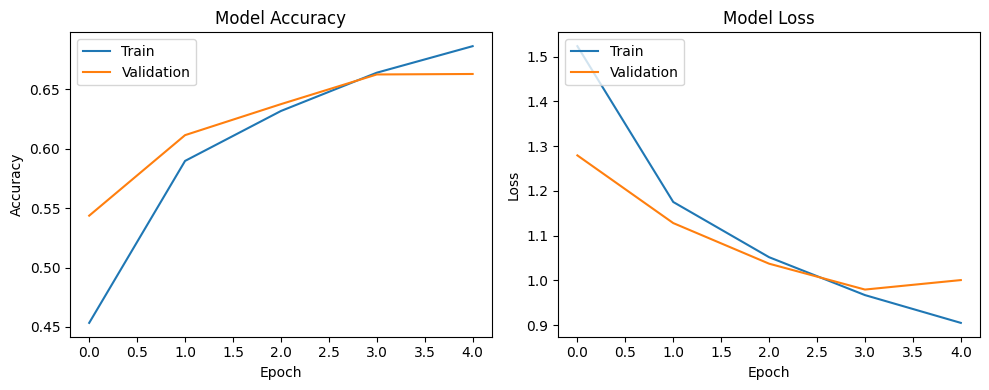

In [25]:
# Plot training history
plt.figure(figsize=(10, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()